# USING OUR OWN CLIP ENCODER

In [1]:
#ALL THE IMPORTS NEEDED
import torch
from torch import autocast
from diffusers.schedulers.scheduling_ddim import DDIMScheduler
from tqdm import tqdm
from PIL import Image
from diffusers import UNet2DConditionModel
from diffusers import AutoencoderKL
from diffusers import LMSDiscreteScheduler
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer



In [ ]:
# CREATING OUR OWN DIFFUSION MODEL CLASS:
class OwnDiffusion:

    def __init__(self, device, vae, tokenizer, text_encoder, unet, scheduler):
        self.vae = vae
        self.device = device
        self.tokenizer = tokenizer
        self.scheduler = scheduler
        self.unet = unet
        self.text_encoder = text_encoder

    
    def extract_prompt_embeddings(self, text, bert):
        """
        This function generates prompt embeddings by combining
        unconditional and conditional embeddings.
        It encourages diversity in outputs while controlling the guidance scale.
        """
        # Tokenize the text
        text_input = self.tokenizer(text, 
                                    padding='max_length', 
                                    max_length=self.tokenizer.model_max_length, 
                                    truncation=True, 
                                    return_tensors='pt')
    
        empty_text = self.tokenizer([''] * len(text), 
                   padding='max_length', 
                   max_length=self.tokenizer.model_max_length, 
                   truncation=True, 
                   return_tensors='pt')

        if bert:
            
            input_ids = text_input['input_ids'].to(device)
            attention_mask = text_input['attention_mask'].to(device)
            
            input_ids2 = empty_text['input_ids'].to(device)
            attention_mask2 = empty_text['attention_mask'].to(device)
            
            with torch.no_grad():
                # Get conditional embeddings with attention mask
                conditional_embeddings = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
                conditional_embeddings = torch.stack(conditional_embeddings[1:], dim=0).squeeze(1)
                
                #print("size of conditional_embeddings", conditional_embeddings.shape)
                # Get unconditional embeddings (for the same number of inputs as text)
                unconditional_embeddings = self.text_encoder(input_ids=input_ids2, attention_mask=attention_mask2)
                unconditional_embeddings = torch.stack(unconditional_embeddings[1:], dim=0).squeeze(1)
                #print("size of unconditional_embeddin", unconditional_embeddings.shape)
        else: 
            with torch.no_grad():
                # Get conditional embeddings
                conditional_embeddings = self.text_encoder(text_input.input_ids.to(self.device))[0]
                print("size of clipconditional_embeddings", conditional_embeddings.shape)

                # Get unconditional embeddings (for the same number of inputs as text)
                unconditional_embeddings = self.text_encoder(empty_text.input_ids.to(self.device))[0]
                print("size of clipunconditional_embeddin", unconditional_embeddings.shape)

        # Concatenate unconditional and conditional embeddings
        prompt_embeddings = torch.cat([unconditional_embeddings, conditional_embeddings])
        return prompt_embeddings


    def update_latents(self, text_embeddings, img_height, img_width, num_steps, scale_factor=8, latents=None):
        if latents is None: #start with random if latent is none ( beginning of the denoise process)
            latents = torch.randn((text_embeddings.shape[0] // 2, self.unet.in_channels,img_height// 8, img_width // 8)).to(self.device)
            #latents = torch.randn((1, 4, 64, 64)).to(device)

        
        self.scheduler.set_timesteps(num_steps)  #number of steps for the scheduler
        # sigma represents the current noise level for the diffusion step
        # The initial latent scaled by the initial sigma 
        latents = latents * self.scheduler.sigmas[0]

        # Perform reverse diffusion (sampling)
        with autocast('cuda'): #Performance Optimization and Reduced Memory Usage:
            for i, t in tqdm(enumerate(self.scheduler.timesteps)):
                #collect the sigma
                sigma = self.scheduler.sigmas[i] 

                # forward pass (conditional + unconditional latents)
                input_latent = latents.repeat(2, *[1] * (latents.dim() - 1)) #repeat() to duplicate the latents tensor along the first dimension while keeping the other dimensions unchanged
                input_latent = input_latent / ((sigma **2 + 1) ** 0.5) # The equation (sigma^2 + 1)^0.5 is derived from the denoising process where each step is designed to remove noise in a way that maintains the overall distribution of the latents.
                
                # Compute the noise prediction using the diffusion model
                with torch.no_grad():
                    noise_pred = self.unet(input_latent, t, encoder_hidden_states=text_embeddings)['sample']

                # split predictions into unconditional and conditional outputs
                batch_size = noise_pred.shape[0] // 2
                unconditional_noise_pred = noise_pred[:batch_size]
                conditional_noise_pred = noise_pred[batch_size:]

                # total noise prediction using the guidance scale
                noise_pred = unconditional_noise_pred + scale_factor * (conditional_noise_pred - unconditional_noise_pred)

                # update the latents by removing the noise prediction at the current sample
                latents = self.scheduler.step(noise_pred, t, latents)['prev_sample']

        return latents

    
    def vae_decoder(self, latents, scaling_factor=0.19):
        """
        Decodes latent representations into images using the VAE (Variational Autoencoder) decoder.
    
        This function takes latent representations as input, rescales them using a specified scaling 
        factor, and then uses the VAE decoder to generate corresponding image samples. The decoded 
        images are returned as tensors on the CPU.
    
        Args:
            latents (torch.Tensor): A tensor containing latent representations of shape 
                                    (batch_size, latent_dim, height, width) used as input for the 
                                    VAE decoder.
            scaling_factor (float, optional): The factor used to rescale the latents before decoding. 
                                              
    
        Returns:
            torch.Tensor: A tensor of decoded images with the same batch size as the input latents, 
                          moved to the CPU for further processing. The shape will typically be 
                          (batch_size, num_channels, image_height, image_width).
        """

        latents = latents / scaling_factor

        with torch.no_grad():
            image_info = self.vae.decode(latents)["sample"]
    
        image_info = image_info.detach().cpu() #move the image to cpu
        return image_info
    
    def prepare_image_format(self, image_info):
        # Rescale image pixel values from the range [-1, 1] to [0, 1].
        image_info = (image_info + 1) / 2  # Shift and scale to [0, 1]
        image_info = image_info.clamp(0, 1)  # Ensure values are within the valid range.
    
        # Change the shape from (batch_size, channels, height, width) 
        # to (batch_size, height, width, channels) and convert to NumPy arrays.
        image_info = image_info.permute(0, 2, 3, 1).cpu().numpy()  # Move to CPU before converting.
    
        # Convert pixel values to the range [0, 255] and change type to uint8.
        image_info = (image_info * 255).astype(np.uint8)  # Directly convert without rounding.
    
        # Create PIL Image objects from the NumPy arrays for easier handling.
        images = []
        for img in image_info:
            images.append(Image.fromarray(img))    
        return images  # Return the list of PIL Images.

    def main(self, input_prompts, img_height=512, img_width=512, num_steps=55, scale_factor=8, initial_latents=None, bert=False):
    
        # Convert input_prompts to a list if it's a single string
        if type(input_prompts) == str:
            input_prompts = [input_prompts]
            
            # Retrieve the text embeddings for the prompts
            embeddings = self.extract_prompt_embeddings(input_prompts, bert)
        
            # Update the latent representations based on the embeddings
            latent_images = self.update_latents(embeddings,img_height, img_width,num_steps,scale_factor,initial_latents)

            # Decode the latent representations into image data
            decoded_images = self.vae_decoder(latent_images)
        
            # Transform the image data to PIL format for easier handling
            pil_images = self.prepare_image_format(decoded_images)
        
            return pil_images , embeddings

RUNNING THE DIFFUSION MODEL: 

In [ ]:
#!pip install accelerate

device = 'cuda'

diffusion_model_name = "CompVis/stable-diffusion-v1-4"
clip_model_name = "openai/clip-vit-large-patch14"
clip_model_name="openai/clip-vit-base-patch32"

# Load tokenizer and the text encoder
tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
text_encoder = CLIPTextModel.from_pretrained(clip_model_name).to(device)

# Load UNet model
unet = UNet2DConditionModel.from_pretrained(diffusion_model_name, subfolder='unet').to(device)
down_blocks = len(unet.down_blocks)
up_blocks = len(unet.up_blocks)
# TWO VARIANTS OF SCHEDULERS TO USE
lms_sched = LMSDiscreteScheduler(beta_schedule='scaled_linear', beta_start=0.00090,beta_end=0.015, num_train_timesteps=1000)

"""

scheduler_DDIM = DDIMScheduler(beta_start=0.00085, 
                               beta_end=0.012, 
                               beta_schedule='scaled_linear', 
                               num_train_timesteps=1000)

lms_sched = LMSDiscreteScheduler(beta_schedule='scaled_linear', beta_start=0.00090,beta_end=0.015, num_train_timesteps=1000)

lms_sched_karras = LMSDiscreteScheduler(
    beta_start=0.00085,
    beta_end=0.012,
    beta_schedule="scaled_linear",
    num_train_timesteps=1000,
    use_karras_sigmas=True  # Enables Karras Sigma noise scheduling
)

"""








# Load VAE 
vae = AutoencoderKL.from_pretrained(diffusion_model_name, subfolder='vae').to(device)

In [6]:
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

def calculate_clip_score_with_prompt(generated_image, text_prompt, clip_model_name="openai/clip-vit-base-patch32", device="cuda"):
    """
    Calculate the CLIP score between a generated image and a given text prompt.

    Parameters:
    - generated_image (PIL.Image.Image or torch.Tensor): The generated image from the diffusion model.
    - text_prompt (str): The text prompt used to generate the image.
    - clip_model_name (str): The name of the CLIP model to use (default is "openai/clip-vit-large-patch14").
    - device (str): The device to use for computation ("cuda" or "cpu").

    Returns:
    - float: The CLIP score between the generated image and the text prompt.
    """
    # Load the CLIP model and processor
    model = CLIPModel.from_pretrained(clip_model_name).to(device)
    processor = CLIPProcessor.from_pretrained(clip_model_name)

    # Preprocess the generated image if it's a PIL image
    if isinstance(generated_image, Image.Image):
        inputs = processor(images=generated_image, return_tensors="pt").to(device)
    elif isinstance(generated_image, torch.Tensor):
        # If the generated image is already a tensor, ensure it has the correct shape
        if len(generated_image.shape) == 3:  # [C, H, W]
            generated_image = generated_image.unsqueeze(0)  # Add batch dimension
        inputs = {'pixel_values': generated_image.to(device)}
    else:
        raise ValueError("The generated image must be a PIL.Image.Image or a torch.Tensor.")

    # Tokenize and encode the text prompt
    inputs_text = processor(text=[text_prompt], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        text_features = model.get_text_features(**inputs_text)

    # Get the image embedding from CLIP
    with torch.no_grad():
        image_features = model.get_image_features(**inputs)

    # Normalize both embeddings
    image_features = image_features / image_features.norm(dim=-1, keepdim=True)
    text_features = text_features / text_features.norm(dim=-1, keepdim=True)

    # Compute the cosine similarity as the CLIP score
    clip_score = (image_features @ text_features.T).item()

    return clip_score


In [7]:
# CLIP MODEL
model_clip = OwnDiffusion(device, vae, tokenizer, text_encoder, unet, lms_sched)

input_prompts= ["a tiger in a forrest"]

image_info, embeds = model_clip.main(input_prompts)


/tmp/ipykernel_30984/1316481700.py:70: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  latents = torch.randn((text_embeddings.shape[0] // 2, self.unet.in_channels,\


size of clipconditional_embeddings torch.Size([1, 77, 768])
size of clipunconditional_embeddin torch.Size([1, 77, 768])


0it [00:00, ?it/s]/home/student/conda/envs/dml/lib/python3.11/site-packages/diffusers/schedulers/scheduling_lms_discrete.py:396: UserWarning: The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
  warnings.warn(
50it [00:07,  6.54it/s]


In [ ]:
# %%
image_info[0]


# TRAINING BERT

In [9]:
"""import zipfile
import os
import shutil

def extract_and_flatten(zip_file_path, extract_to):
    # Create the extraction directory if it doesn't exist
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    
    # Temporary folder for extraction
    temp_extract_to = os.path.join(extract_to, 'temp')
    
    # Extract all files from the zip
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(temp_extract_to)

    # Walk through the directories and move files to the top level
    for root, dirs, files in os.walk(temp_extract_to):
        for file in files:
            # Create new file path in the root of extract_to
            file_path = os.path.join(root, file)
            destination_path = os.path.join(extract_to, file)
            
            # If file already exists, rename it to avoid conflict
            if os.path.exists(destination_path):
                base, ext = os.path.splitext(file)
                destination_path = os.path.join(extract_to, base + '_duplicate' + ext)
            
            # Move file to the root of extract_to
            shutil.move(file_path, destination_path)

    # Clean up the temporary folder
    shutil.rmtree(temp_extract_to)

# Example usage
#train_zip_path = './train.zip'
test_zip_path = './test.zip'
#extract_to_train = 'train'  # Define where to extract
extract_to_test = 'test'  # Define where to extract


# Extract and flatten both ZIP files
#extract_and_flatten(train_zip_path, extract_to_train)
extract_and_flatten(test_zip_path, extract_to_test)"""


In [10]:
"""import chardet
def convert_txt_files_to_utf8(directory):
    
    for filename in os.listdir(directory):
        if filename.endswith('.txt'):
            file_path = os.path.join(directory, filename)
            try:
                # Detect encoding
                with open(file_path, 'rb') as f:
                    result = chardet.detect(f.read())
                    encoding = result['encoding']
                    print(f"Detected encoding for {filename}: {encoding}")

                # Read the file with detected encoding
                with open(file_path, 'r', encoding=encoding) as f:
                    content = f.read()

                # Write the content back in UTF-8
                with open(file_path, 'w', encoding='utf-8') as f:
                    f.write(content)
                    print(f"Converted {filename} to UTF-8.")
            
            except Exception as e:
                print(f"Error processing {filename}: {e}")

# Example usage
data_dir = './test'  # Update this to your dataset path
convert_txt_files_to_utf8(data_dir)"""

Detected encoding for 000057510.txt: utf-8
Converted 000057510.txt to UTF-8.
Detected encoding for 000058768_duplicate.txt: ascii
Converted 000058768_duplicate.txt to UTF-8.
Detected encoding for 000058470.txt: ascii
Converted 000058470.txt to UTF-8.
Detected encoding for 000057343.txt: ascii
Converted 000057343.txt to UTF-8.
Detected encoding for 000058694.txt: ascii
Converted 000058694.txt to UTF-8.
Detected encoding for 000057613_duplicate.txt: ascii
Converted 000057613_duplicate.txt to UTF-8.
Detected encoding for 000057204.txt: ascii
Converted 000057204.txt to UTF-8.
Detected encoding for 000057728.txt: ascii
Converted 000057728.txt to UTF-8.
Detected encoding for 000057874.txt: ascii
Converted 000057874.txt to UTF-8.
Detected encoding for 000057937_duplicate.txt: ascii
Converted 000057937_duplicate.txt to UTF-8.
Detected encoding for 000057830_duplicate.txt: ascii
Converted 000057830_duplicate.txt to UTF-8.
Detected encoding for 000057209_duplicate.txt: ascii
Converted 000057209_

In [11]:
def weighted_avg(x, weights):
    """Weighted average
    Calculates a weighted average of a batch of sequences of vectors.

    Args:
        x (torch.Tensor): Shape (batch_size, dim, seq_len)

        weights (torch.Tensor): Shape (batch_size, seq_len, seq_len)

    Returns:
        y (torch.Tensor): Shape (batch_size, dim, seq_len)
    """
    # YOUR CODE HERE

    #batch here is many sentences. Each sentence contains its own words. so basically this claulation is done to each sample "sentence"
    #seq_len: Number of words in each sentence (the length of the sequence).
    #dim: Dimensionality of each word embedding.
    
    return torch.bmm(x,weights)

In [12]:
def normalized_dot_product(v_1, v_2):
    """Normalized dot products between all pairs of vectors in a sequence
    Takes two batches of sequences of vectors as input.
    Sequences in the batch are processed independently.
    The normalization is done with a softmax function along the columns of the weight matrices.

    Args:
        v_1 (torch.Tensor): Shape (batch_size, dim, seq_len)
        v_2 (torch.Tensor): Shape (batch_size, dim, seq_len)

    Returns:
        norm_dot_prod (torch.Tensor): Shape (batch_size, seq_len, seq_len)
    """
    # YOUR CODE HERE
    # Compute the dot product using batched matrix multiplication
    dot_product = torch.bmm(v_1.transpose(1, 2), v_2)

    # Apply softmax along the appropriate dimension (seq_len dimension)
    norm_dot_prod = torch.softmax(dot_product, dim=1) #dim 1 so that we apply along the rows.
    return norm_dot_prod


In [13]:
def query_key_weights(queries, keys):
    """Weights from query-key dot product.
    Softmax-normalised dot product weights
    Calculates weights for a batch of sequences of vectors.

    Args:
        queries (torch.Tensor): Shape (batch_size, dim, seq_len)
        keys (torch.Tensor): Shape (batch_size, dim, seq_len)

    Returns:
        weights (torch.Tensor): Shape (batch_size, seq_len, seq_len)
    """
    dim = queries.shape[1]
    # YOUR CODE HERE
    weights = normalized_dot_product(queries / (dim **0.25), keys / (dim **0.25))

    return weights

In [14]:
from einops import rearrange
import torch
import torch.nn as nn


class SelfAttention(nn.Module):
    def __init__(self, dim, heads):
        """Self-attention module

        Args:
            dim (int): The full embedding dimension of the input vectors
            heads (int): The number of heads in the multi-head attention.
        """
        super().__init__()
        if not dim % heads == 0:
            raise ValueError(
                "The embedding dim. must be divisible by the number of heads for the vectorization to work."
            )
        self.dim = dim
        self.heads = heads
        head_dim = dim // heads
        # Linear maps for q, k and v
        self.Wq = nn.Linear(dim, heads * head_dim, bias=False)
        self.Wk = nn.Linear(dim, heads * head_dim, bias=False)
        self.Wv = nn.Linear(dim, heads * head_dim, bias=False)
        # Linear mapping to return to the original
        self.WO = nn.Linear(heads * head_dim, dim)

    def forward(self, x):
        """Multi-headed self attention

        Each head operates on a part of the embedding, i.e. we have q, k and v with shape
        (batch_size, seq_length, heads, dim / heads)

        Args:
            x (Tensor): Input with shape (batch_size, seq_length, dim)
        """

        # The input is projected with the three different linear maps
        # and reshaped to combine the batch and head dimensions for efficiency.
        keys = rearrange(self.Wk(x), "b s (h d) -> (b h) d s", h=self.heads)
        queries = rearrange(self.Wq(x), "b s (h d) -> (b h) d s", h=self.heads)
        values = rearrange(self.Wv(x), "b s (h d) -> (b h) d s", h=self.heads)

        # The weights are calculated from the query-key dot product
        weights = query_key_weights(queries, keys)

        # The output is the weighted average of the values
        y_tilde = weighted_avg(values, weights)

        # The output is reshaped to a suitable shape before projected back to the original dimension
        y_tilde = rearrange(y_tilde, "(b h) d s -> b s (h d)", h=self.heads)

        return self.WO(y_tilde), weights

In [15]:
class TransformerBlock(nn.Module):
    """Transformer block"""

    def __init__(self, dim, heads):
        super().__init__()

        self.self_attention = SelfAttention(dim, heads)

        self.normalization_1 = nn.LayerNorm(dim)
        self.normalization_2 = nn.LayerNorm(dim)

        # The size of the hidden layer is a hyper-parameter,
        # but the consensus is that it should at least be larger than the input/output size
        self.feed_forward = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.ReLU(),
            nn.Linear(4 * dim, dim),
        )

    def forward(self, x):
        """Forward pass of Transformer block

        Args:
            x (torch.Tensor): Input with shape (batch_size, seq_length, dim)

        Returns:
            y (torch.Tensor): Output with shape (batch_size, seq_length, dim)
            attention_weights (torch.Tensor): Weights for the attention layer with shape (batch_size, seq_length, seq_length).
        """
        # YOUR CODE HERE

        # Self-attention with residual connection
        y_tilde, attention_weights = self.self_attention(x)
        x = self.normalization_1(y_tilde + x)
    
        # Feedforward with residual connection
        y = self.feed_forward(x) #In the Transformer architecture, each token (or word) in the input sequence is transformed into a vector of size dim. This means for every word, there are dim values, and each value can be thought of as being processed by one "input neuron."
        y = self.normalization_2(y + x)
        return y, attention_weights

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoModel, BertTokenizer

class BERTEncoder(nn.Module):
    def __init__(self, diffusion_model_name="bert-base-uncased", seq_length=77):
        super().__init__()
        self.bert = AutoModel.from_pretrained(diffusion_model_name)
        self.output_size = self.bert.config.hidden_size  # This should be 768 for BERT
        self.seq_length = seq_length

    def forward(self, input_ids, attention_mask):
        """Forward pass of BERT encoder."""
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        last_hidden_state = out.last_hidden_state
        
        # Create a zero tensor to pad the output to seq_length
        if last_hidden_state.shape[1] < self.seq_length:
            # Pad with zeros
            padding_size = self.seq_length - last_hidden_state.shape[1]
            padding_tensor = torch.zeros((last_hidden_state.shape[0], padding_size, self.output_size), device=last_hidden_state.device)
            last_hidden_state = torch.cat((last_hidden_state, padding_tensor), dim=1)
        elif last_hidden_state.shape[1] > self.seq_length:
            # Truncate the output to seq_length
            last_hidden_state = last_hidden_state[:, :self.seq_length, :]

        return last_hidden_state, out.attentions  # Shape: [Batch Size, Seq Length, Embedding Dimension]

class Transformer(nn.Module):
    def __init__(self, in_dim, dim, heads, depth, seq_length):
        super().__init__()

        self.input_map = nn.Linear(in_dim, dim)
        self.pos_emb = nn.Embedding(seq_length, dim)
        self.max_seq_length = seq_length

        # Stack of transformer blocks
        self.transformer_blocks = nn.ModuleList([TransformerBlock(dim=dim, heads=heads) for _ in range(depth)])

    def forward(self, x):
        batch_size, seq_length, _ = x.shape  # [Batch Size, Seq Length, Embedding Dimension]
        x = self.input_map(x)

        if seq_length > self.max_seq_length:
            x = x[:, :self.max_seq_length]

        pos = torch.arange(seq_length, device=x.device).unsqueeze(0)  # [1, Seq Length]
        pos_embedding = self.pos_emb(pos)  # [1, Seq Length, Dim]
        x = x + pos_embedding

        for block in self.transformer_blocks:
            x, _ = block(x)  # Assuming the block returns (x, attention_weights)

        return x  # Output shape remains [Batch Size, Seq Length, Dim]


In [17]:

class ImdbClassifier(nn.Module):
    def __init__(self, dim, heads, depth, seq_length, freeze_encoder=True):
        super().__init__()
        self.bert = BERTEncoder(seq_length=seq_length)  # Ensure seq_length is set to 77
        if freeze_encoder:
            for param in self.bert.parameters():
                param.requires_grad = False

        self.transformer = Transformer(
            self.bert.output_size, dim, heads, depth, seq_length
        )

    def forward(self, input_ids, attention_mask):
        x, _ = self.bert(input_ids=input_ids, attention_mask= attention_mask)
        x = self.transformer(x)

        # Extract the [CLS] token representation for contrastive learning
        cls_embedding = x[:, 0, :]  # Shape: [Batch Size, Embedding Dimension]
        return cls_embedding, x  # Return both [CLS] and full output if needed

##  The training loop

In [18]:
from time import time

def train_epoch(model, train_loader, optimizer, scheduler, device):
    """Train epoch"""
    train_loss = AccumulatingMetric()
    train_acc = AccumulatingMetric()
    model.train()
    for batch in train_loader:
        optimizer.zero_grad()
        for key, val in batch.items():
            batch[key] = val.to(device)
        label = batch["labels"]
        pred, _ = model(batch["input_ids"], batch["attention_mask"])
        loss = F.nll_loss(pred, label)
        loss.backward()
        train_loss.add(loss.item())

        train_acc.add(accuracy(pred, label))

        optimizer.step()
        scheduler.step()
    return train_loss.avg(), train_acc.avg()

def accuracy(pred, label):
    hard_pred = pred.argmax(1)
    return (hard_pred == label).float().mean().item()


def _truncate_input(input_, max_seq_len):
    if input_.size(1) > max_seq_len:
        input_ = input_[:, :max_seq_len]
    return input_


class AccumulatingMetric:
    """Accumulate samples of a metric and automatically keep track of the number of samples."""

    def __init__(self):
        self.metric = 0.0
        self.counter = 0

    def add(self, value):
        self.metric += value
        self.counter += 1

    def avg(self):
        return self.metric / self.counter

In [19]:
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import BertTokenizer, BertModel, AdamW
from torchvision import transforms
from PIL import Image
import os


def calculate_mean_std(dataset, batch_size=32):
    # DataLoader to iterate over the dataset
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    # Variables to store the sum of pixel values and sum of squared pixel values
    mean = torch.zeros(3)
    std = torch.zeros(3)
    total_images_count = 0

    # Iterate over the DataLoader
    for images, _ in loader:
        # Reshape to (batch_size, 3, H, W) -> (batch_size, 3, H * W)
        images = images.view(images.size(0), images.size(1), -1)
        
        # Update the mean and std calculations
        mean += images.mean(2).sum(0)
        std += images.std(2).sum(0)
        total_images_count += images.size(0)

    # Calculate the final mean and std
    mean /= total_images_count
    std /= total_images_count

    return mean, std




class ImageTextDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        super().__init__()
        self.data_dir = data_dir
        self.transform = transform

        # Get all .jpg files and check for corresponding non-empty .txt files
        self.image_filenames = sorted([f for f in os.listdir(data_dir) if f.endswith(".jpg")])
        
        # Filter out pairs with empty or missing captions
        self.image_filenames = [
            f for f in self.image_filenames 
            if os.path.exists(os.path.join(data_dir, f.replace(".jpg", ".txt"))) 
            and os.path.getsize(os.path.join(data_dir, f.replace(".jpg", ".txt"))) > 0
        ]
        
        print(f"Total valid image-caption pairs: {len(self.image_filenames)}")

    
    def __len__(self):
        return len(self.image_filenames)

    
    def __getitem__(self, idx):
        img_name = self.image_filenames[idx]
        img_path = os.path.join(self.data_dir, img_name)
    
        # Load image
        try:
            image = Image.open(img_path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error loading image {img_name}: {e}")
    
        # Load corresponding caption
        caption_file = img_name.replace(".jpg", ".txt")
        caption_path = os.path.join(self.data_dir, caption_file)

        
        try:
            with open(caption_path, "r") as file:
                caption = file.read().strip()
        except Exception as e:
            raise RuntimeError(f"Error loading caption {caption_file}: {e}")
        if self.transform:
            image = self.transform(image)
   
        return image, caption



In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import BertTokenizer, CLIPModel, CLIPProcessor
from torchvision import transforms
from PIL import Image
def train_bert_contrastive(data_dir, bert_model_name='bert-base-uncased', 
                           batch_size=16, epochs=10, learning_rate=1e-5, device='cuda'):
    # Set device
    device = device if torch.cuda.is_available() else 'cpu'

    # Initialize tokenizer
    tokenizer = BertTokenizer.from_pretrained(bert_model_name)
    
    # Initialize the ImdbClassifier model
    dim = 768  # Assuming the embedding dimension is 768
    heads = 8
    depth = 6
    seq_length = 77  # BERT typically has a max sequence length of 512; CLIP's standard is 77
    imdb_model = ImdbClassifier(dim=dim, heads=heads, depth=depth, seq_length=seq_length).to(device)
    
    # Initialize image transformations
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])

    # Prepare the dataset and dataloader
    dataset = ImageTextDataset(data_dir=data_dir, transform=transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # Optimizer
    optimizer = AdamW(imdb_model.parameters(), lr=learning_rate)

    # Training loop
    for epoch in range(epochs):
        imdb_model.train()
        total_loss = 0.0

        for batch in dataloader:
            images, captions = batch
            
            # Move images to device
            images = images.to(device)

            # Tokenize captions
            inputs = tokenizer(captions, return_tensors='pt', padding='max_length', 
                               truncation=True, max_length=seq_length)
            input_ids = inputs['input_ids'].to(device)
            attention_mask = inputs['attention_mask'].to(device)

            # Forward pass through ImdbClassifier to get text embeddings
            text_embeddings, _ = imdb_model(input_ids=input_ids, attention_mask=attention_mask)

            # Get image embeddings from a pre-trained image encoder
            image_embeddings = get_image_embeddings(images).to(device)

            # Contrastive loss between text and image embeddings
            loss = contrastive_loss(text_embeddings, image_embeddings)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(dataloader)}")
    
    # Save the model after training
    torch.save(imdb_model.state_dict(), 'imdb_classifier.pth')  # Save the model's state dict
    print("Model saved to imdb_classifier.pth")
    return imdb_model
def contrastive_loss(text_embeddings, image_embeddings, temperature=0.07):
    # Normalize embeddings
    text_embeddings = torch.nn.functional.normalize(text_embeddings, dim=-1)
    image_embeddings = torch.nn.functional.normalize(image_embeddings, dim=-1)
    # Compute similarity matrix
    logits = torch.matmul(text_embeddings, image_embeddings.T) / temperature
    # Labels for contrastive loss
    labels = torch.arange(logits.size(0)).to(logits.device)
    # Contrastive loss (cross entropy)
    loss = torch.nn.CrossEntropyLoss()(logits, labels)
    return loss


def get_image_embeddings(images):
    # Load the pretrained CLIP model and processor
    clip_model_name = "openai/clip-vit-large-patch14"
    clip_model = CLIPModel.from_pretrained(clip_model_name).to(device)
    clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
        
    # Preprocess the images to the format expected by CLIP
    processed = clip_processor(images=images, return_tensors="pt").to(images.device)
    
    # Pass the processed images through the CLIP model to get the image embeddings
    with torch.no_grad():
        image_embeddings = clip_model.get_image_features(**processed)
    
    # Normalize the embeddings (helps with stability)
    image_embeddings = image_embeddings / image_embeddings.norm(dim=-1, keepdim=True)
    return image_embeddings

# Example usage
#data_dir = "./train"  # Update this to your dataset path
#bert_model = train_bert_contrastive(data_dir)


In [21]:
# Initialize the ImdbClassifier model
dim = 768  # Assuming the embedding dimension is 768
heads = 8
depth = 6
seq_length = 77  # BERT typically has a max sequence length of 512; CLIP's standard is 77
bert_model = ImdbClassifier(dim=dim, heads=heads, depth=depth, seq_length=seq_length).to(device)

# Load the model's state dict
bert_model.load_state_dict(torch.load('imdb_classifier.pth'))
print("Model loaded from imdb_classifier.pth")


Model loaded from imdb_classifier.pth


 # CALCULATE SCORES

In [22]:
#!pip install git+https://github.com/openai/CLIP.git


In [23]:
import clip
import torch
from PIL import Image
import torchvision.transforms as transforms
import torch
from PIL import Image
import torchvision.transforms as transforms

def calculate_image_similarity(model, preprocess, generated_image, reference_image, diffusion_model_name="ViT-B/32", device="cuda"):
    """
    Calculate the similarity between a generated image and a reference image using CLIP.

    Parameters:
    - generated_image (PIL.Image.Image or torch.Tensor): The generated image from the diffusion model.
    - reference_image (PIL.Image.Image or torch.Tensor): The reference image to compare against.
    - diffusion_model_name (str): The name of the CLIP model to use (default is "ViT-B/32").
    - device (str): The device to use for computation ("cuda" or "cpu").

    Returns:
    - float: The similarity score between the generated image and the reference image.
    """

    # Create a transform to resize images to 224x224
    resize_transform = transforms.Resize((224, 224))

    # Preprocess the image based on its type
    def preprocess_image(image):
        if isinstance(image, Image.Image):
            # Resize and convert to tensor
            image = resize_transform(image)
            image = preprocess(image).unsqueeze(0).to(device)
        elif isinstance(image, torch.Tensor):
            # If the image is already a tensor, ensure it has the correct shape
            if len(image.shape) == 3:  # [C, H, W]
                image = image.permute(1, 2, 0)  # Change shape to [H, W, C] for resizing
                image = resize_transform(Image.fromarray((image.numpy() * 255).astype('uint8')))  # Convert to PIL for resizing
                image = preprocess(image).unsqueeze(0).to(device)  # Convert to tensor and add batch dimension
            else:
                raise ValueError("The tensor must have 3 dimensions [C, H, W].")
        else:
            raise ValueError("The image must be a PIL.Image.Image or a torch.Tensor.")
        return image

    # Preprocess both images
    generated_image = preprocess_image(generated_image)
    reference_image = preprocess_image(reference_image)
    print("Size of reference image:", reference_image.size())
    print("Size of generated image:", generated_image.size())

    # Get the embeddings for both images using CLIP
    with torch.no_grad():
        generated_image_features = model.encode_image(generated_image)
        reference_image_features = model.encode_image(reference_image)

    # Normalize the image embeddings
    generated_image_features = generated_image_features / generated_image_features.norm(dim=-1, keepdim=True)
    reference_image_features = reference_image_features / reference_image_features.norm(dim=-1, keepdim=True)

    # Compute the cosine similarity between the two image features
    similarity_score = (generated_image_features @ reference_image_features.T).item()

    return similarity_score



In [24]:
import lpips
import torchvision.transforms as transforms

def calculate_lpips_score(generated_image, reference_image, device="cuda"):
    """
    Calculate the LPIPS score between a generated image and a reference image.

    Parameters:
    - generated_image (PIL.Image.Image or torch.Tensor): The generated image from the diffusion model.
    - reference_image (PIL.Image.Image or torch.Tensor): The reference image from the dataset.
    - device (str): The device to use for computation ("cuda").

    Returns:
    - float: The LPIPS score between the generated image and the reference image.
    """
    # Initialize the LPIPS model
    lpips_model = lpips.LPIPS(net='vgg').to(device)

    # Preprocess the images
    transform = transforms.Compose([
        transforms.Resize((256, 256)),  # Resize the images for LPIPS computation
        transforms.ToTensor(),
    ])

    # Convert images to tensors if they are in PIL format
    if isinstance(generated_image, Image.Image):
        generated_image = transform(generated_image).unsqueeze(0).to(device)  # Add batch dimension
    elif isinstance(generated_image, torch.Tensor):
        generated_image = generated_image.to(device)
    else:
        raise ValueError("The generated image must be a PIL.Image.Image or a torch.Tensor.")
    
    if isinstance(reference_image, Image.Image):
        reference_image = transform(reference_image).unsqueeze(0).to(device)  # Add batch dimension
    elif isinstance(reference_image, torch.Tensor):
        reference_image = reference_image.to(device)
    else:
        raise ValueError("The reference image must be a PIL.Image.Image or a torch.Tensor.")
    
    # Compute the LPIPS score
    with torch.no_grad():
        lpips_score = lpips_model(generated_image, reference_image).item()

    return lpips_score

In [25]:
import torch
import numpy as np
from scipy.linalg import sqrtm
from torchvision.models import inception_v3
from torchvision import transforms
from PIL import Image

def calculate_fid_score_batch(generated_images, reference_images, device="cuda" if torch.cuda.is_available() else "cpu"):
    """
    Calculate the FID score between batches of generated images and reference images.

    Parameters:
    - generated_images (list of PIL.Image.Image or torch.Tensor): List of generated images.
    - reference_images (list of PIL.Image.Image or torch.Tensor): List of reference images.
    - device (str): The device to use for computation ("cuda" or "cpu").

    Returns:
    - float: The FID score between the generated images and the reference images.
    """
    # Load the Inception v3 model for feature extraction
    inception_model = inception_v3(pretrained=True, transform_input=False).to(device)
    inception_model.eval()  # Set to evaluation mode

    # Preprocess images for Inception v3
    transform = transforms.Compose([
        transforms.Resize((299, 299)),  # Inception v3 expects images of this size
        transforms.ToTensor(),
    ])

    def preprocess_images(images):
        preprocessed_images = []
        for image in images:
            if isinstance(image, Image.Image):
                image = transform(image)  # Transform to tensor
            elif isinstance(image, torch.Tensor):
                image = image  # Already a tensor
            else:
                raise ValueError("The image must be a PIL.Image.Image or a torch.Tensor.")
            preprocessed_images.append(image)
        # Stack the list of tensors into a single tensor
        return torch.stack(preprocessed_images).to(device)  # Add batch dimension

    def get_inception_features(images):
        # Preprocess all images and move to device
        preprocessed_images = preprocess_images(images)
        with torch.no_grad():
            features = inception_model(preprocessed_images)
        return features.cpu().numpy()

    # Collect features for generated and reference images
    generated_features = get_inception_features(generated_images)
    reference_features = get_inception_features(reference_images)

    # Ensure we have enough samples to compute covariance matrices
    if generated_features.shape[0] < 2 or reference_features.shape[0] < 2:
        raise ValueError("Need at least two images per batch to compute covariance matrices.")

    # Calculate the mean and covariance for the features
    mu_generated = np.mean(generated_features, axis=0)
    sigma_generated = np.cov(generated_features, rowvar=False) * 1e-6
    mu_reference = np.mean(reference_features, axis=0)
    sigma_reference = np.cov(reference_features, rowvar=False) * 1e-6

    # Calculate the squared difference between means
    diff = mu_generated - mu_reference
    # Calculate the product of the covariances and take the square root
    covmean, _ = sqrtm(sigma_generated.dot(sigma_reference), disp=False)

    # Handle numerical errors
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Calculate the FID score
    fid_score = diff.dot(diff) + np.trace(sigma_generated + sigma_reference - 2 * covmean)

    return fid_score


In [26]:
model, preprocess = clip.load("ViT-B/32", device=device)


In [27]:
import torch
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertModel
from PIL import Image
import torchvision.transforms as transforms
from torchvision.transforms import ToPILImage
to_pil_image = ToPILImage()
import matplotlib.pyplot as plt



def prepare_image_format(image_info):
    # Rescale image pixel values from the range [-1, 1] to [0, 1].
    image_info = (image_info + 1) / 2  # Shift and scale to [0, 1]
    image_info = image_info.clamp(0, 1)  # Ensure values are within the valid range.

    # Change the shape from (batch_size, channels, height, width) 
    # to (batch_size, height, width, channels) and convert to NumPy arrays.
    image_info = image_info.permute(0, 2, 3, 1).cpu().numpy()  # Move to CPU before converting.

    # Convert pixel values to the range [0, 255] and change type to uint8.
    image_info = (image_info * 255).astype(np.uint8)  # Directly convert without rounding.

    # Create PIL Image objects from the NumPy arrays for easier handling.
    images = [Image.fromarray(image) for image in image_info]  # Use 'images' for clarity.

    return images  # Return the list of PIL Images.



# Set up device
device = 'cuda'

# Initialize BERT tokenizer and model
bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

clip_model_name = "openai/clip-vit-base-patch32"

# Initialize CLIP tokenizer and model
clip_tokenizer = CLIPTokenizer.from_pretrained(clip_model_name)
clip_text_encoder = CLIPTextModel.from_pretrained(clip_model_name).to(device)
diffusion_model_name = "CompVis/stable-diffusion-v1-4"

# Diffusion model with scheduler, vae, unet, etc.
model_clip = OwnDiffusion(device, vae, clip_tokenizer, clip_text_encoder, unet, lms_sched)

model_bert = OwnDiffusion(device, vae, bert_tokenizer, bert_model , unet, lms_sched)

# Initialize image transformations
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

# Prepare the dataset and dataloader
data_dir = "./test"  # Update this to your dataset path
dataset = ImageTextDataset(data_dir=data_dir, transform=transform)
mean, std = calculate_mean_std(dataset)

# Use the calculated mean and std for normalization
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])
batch_size = 32

# Update the dataset with the new transform
dataset = ImageTextDataset(data_dir=data_dir, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Dictionaries to store results
lpips_scores_bert = {}
similarity_scores_bert = {}
lpips_scores_clip = {}
similarity_scores_clip = {}
fid_scores_bert = {}
fid_scores_clip = {}
images = []
list_captions = []

# Generate images and calculate scores
for batch_idx, (image, caption) in enumerate(dataloader):
    caption_text = caption[0]
    caption_length = len(caption_text)

    # Generate images using the models
    image_info_clip, embeddings_clip = model_clip.main(caption_text, bert=False)
    image_info_bert, embeddings_bert = model_bert.main(caption_text, bert=True)
    
    print("Size of image_info_bert:", image_info_bert[0].size)
    print("Size of image:", image[0].size)

    # Calculate LPIPS score for BERT
    lpips_score_bert = calculate_lpips_score(image_info_bert[0], image[0], device)
    lpips_scores_bert[lpips_score_bert] = caption_length

    # Calculate image similarity score for BERT
    similarity_score_bert = calculate_image_similarity(model, preprocess,image_info_bert[0], image[0], device=device)
    similarity_scores_bert[similarity_score_bert] = caption_length

    # Calculate LPIPS score for CLIP
    lpips_score_clip = calculate_lpips_score(image_info_clip[0], image[0], device)
    lpips_scores_clip[lpips_score_clip] = caption_length

    # Calculate image similarity score for CLIP
    similarity_score_clip = calculate_image_similarity(model, preprocess,image_info_clip[0], image[0], device=device)
    similarity_scores_clip[similarity_score_clip] = caption_length

    # Calculate FID score for CLIP
    fid_score_clip = calculate_fid_score_batch([image_info_clip[0], image_info_clip[0]], [image[0],image[0]], device=device)
    fid_scores_clip[fid_score_clip] = caption_length
    
    # Calculate FID score for BERT
    fid_score_bert = calculate_fid_score_batch([image_info_bert[0], image_info_bert[0]], [image[0],image[0]], device=device)
    fid_scores_bert[fid_score_bert] = caption_length

    # Save the generated images
    if batch_idx < 10:
        image_info_bert[0].save(f'./output_images/generated_image_bert/generated_image_bert_{batch_idx}.png')
        image_info_clip[0].save(f'./output_images/generated_image_clip/generated_image_clip_{batch_idx}.png')
        image = prepare_image_format(image)
        images.append(image)
        list_captions.append(caption_text)

Total valid image-caption pairs: 2264


/tmp/ipykernel_30984/1316481700.py:70: FutureWarning: Accessing config attribute `in_channels` directly via 'UNet2DConditionModel' object attribute is deprecated. Please access 'in_channels' over 'UNet2DConditionModel's config object instead, e.g. 'unet.config.in_channels'.
  latents = torch.randn((text_embeddings.shape[0] // 2, self.unet.in_channels,\


Total valid image-caption pairs: 2264
size of clipconditional_embeddings torch.Size([1, 77, 768])
size of clipunconditional_embeddin torch.Size([1, 77, 768])


0it [00:00, ?it/s]/home/student/conda/envs/dml/lib/python3.11/site-packages/diffusers/schedulers/scheduling_lms_discrete.py:396: UserWarning: The `scale_model_input` function should be called before `step` to ensure correct denoising. See `StableDiffusionPipeline` for a usage example.
  warnings.warn(
50it [00:07,  6.58it/s]


size of conditional_embeddings torch.Size([1, 77, 768])
size of unconditional_embeddin torch.Size([1, 77, 768])


...

Size of image_info_bert: (512, 512)
Size of image: <built-in method size of Tensor object at 0x7ff20c262390>
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/student/conda/envs/dml/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Size of reference image: torch.Size([1, 3, 224, 224])
Size of generated image: torch.Size([1, 3, 224, 224])
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/student/conda/envs/dml/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Size of reference image: torch.Size([1, 3, 224, 224])
Size of generated image: torch.Size([1, 3, 224, 224])
size of clipconditional_embeddings torch.Size([1, 77, 768])
size of clipunconditional_embeddin torch.Size([1, 77, 768])


50it [00:08,  6.21it/s]


size of conditional_embeddings torch.Size([1, 77, 768])
size of unconditional_embeddin torch.Size([1, 77, 768])


50it [00:08,  6.23it/s]


Size of image_info_bert: (512, 512)
Size of image: <built-in method size of Tensor object at 0x7ff20c262390>
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/student/conda/envs/dml/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Size of reference image: torch.Size([1, 3, 224, 224])
Size of generated image: torch.Size([1, 3, 224, 224])
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]
Loading model from: /home/student/conda/envs/dml/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth
Size of reference image: torch.Size([1, 3, 224, 224])
Size of generated image: torch.Size([1, 3, 224, 224])


In [28]:
print(list_captions[0])

"1 Likes, 1 Comments - Nicole Rovig (@nicolerovig) on Instagram: ""The Healing Garden. #flowers #flowersofinstagram #gardens #naturelover #lavender"""


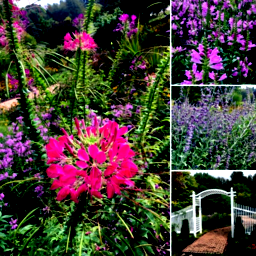

In [29]:
images[0][0]

In [30]:
print(list_captions[1])

Duke Nukem in curand pe Android


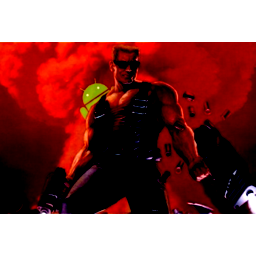

In [31]:
images[1][0]

In [32]:
print(list_captions[2])

"Harry Epworth Allen (English, 1894-1958)  ""Haddon Hall Derbyshire"""


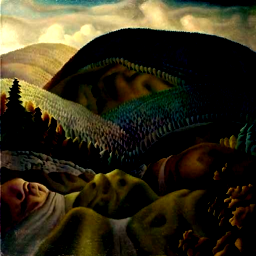

In [33]:
images[2][0]

In [34]:
print(list_captions[3])

Los Angeles Photographer Wedding


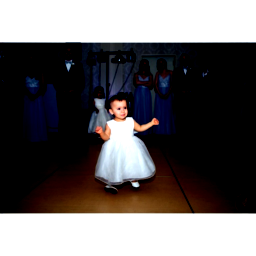

In [35]:
images[3][0]

In [36]:
print(list_captions[4])

Stoneware Tea Set, Glazed Coffee Pot, Hot Chocolate Server


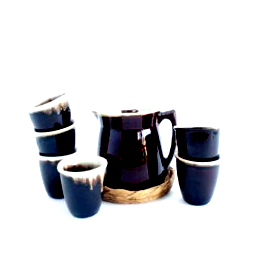

In [37]:
images[4][0]

In [38]:
print(list_captions[5])

handsome, man, sitting, cake shop, cafeteria, room, table, indoors, people, interior design


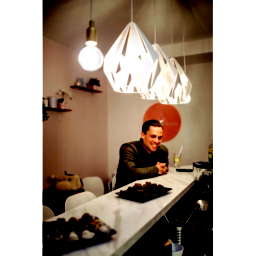

In [39]:
images[5][0]

In [40]:
print(list_captions[6])

Ottawa-Gatineau a reçu sa première tempête de neige de la saison. (Patrick Woodbury, LeDroit)


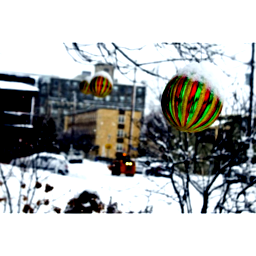

In [41]:
images[6][0]

In [42]:
print(list_captions[7])

Morning on Sprague Lake (Explored)


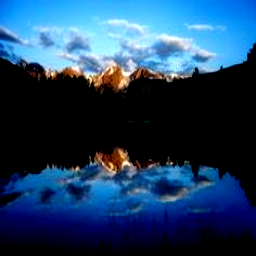

In [43]:
images[7][0]

In [44]:
print(list_captions[8])

Cherry Blossom Needle Minder, Sakura Sewing Needle Buddy, Sewing Accessory, Needle Magnet


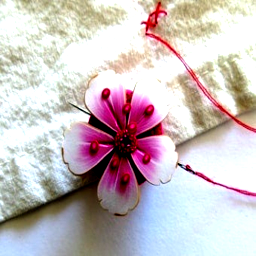

In [45]:
images[8][0]

In [46]:
print(list_captions[9])

Latest 2022 Mercedes-Benz Citan Already A Campervan


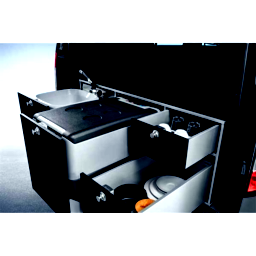

In [47]:
images[9][0]

In [ ]:
import matplotlib.pyplot as plt
"""
def plot_scores_vs_caption_length(bert_scores, clip_scores, score_type):
    bert_lengths = list(bert_scores.values())
    bert_scores_values = list(bert_scores.keys())
    
    clip_lengths = list(clip_scores.values())
    clip_scores_values = list(clip_scores.keys())

    plt.figure(figsize=(12, 6))
    
    # Plot BERT scores
    plt.scatter(bert_lengths, bert_scores_values, label='BERT', color='blue', alpha=0.7)
    plt.plot(bert_lengths, bert_scores_values, color='blue', alpha=0.3)

    # Plot CLIP scores
    plt.scatter(clip_lengths, clip_scores_values, label='CLIP', color='orange', alpha=0.7)
    plt.plot(clip_lengths, clip_scores_values, color='orange', alpha=0.3)

    # Adding titles and labels
    plt.title(f'{score_type} Scores vs. Caption Length')
    plt.xlabel('Caption Length')
    plt.ylabel(f'{score_type} Score')
    plt.legend()
    plt.grid()
    plt.show()

# Generate LPIPS scores vs caption length
plot_scores_vs_caption_length(lpips_scores_bert, lpips_scores_clip, 'LPIPS')

# Generate Similarity scores vs caption length
plot_scores_vs_caption_length(similarity_scores_bert, similarity_scores_clip, 'Similarity')

# Generate FID scores vs caption length
plot_scores_vs_caption_length(fid_scores_bert, fid_scores_clip, 'FID')"""


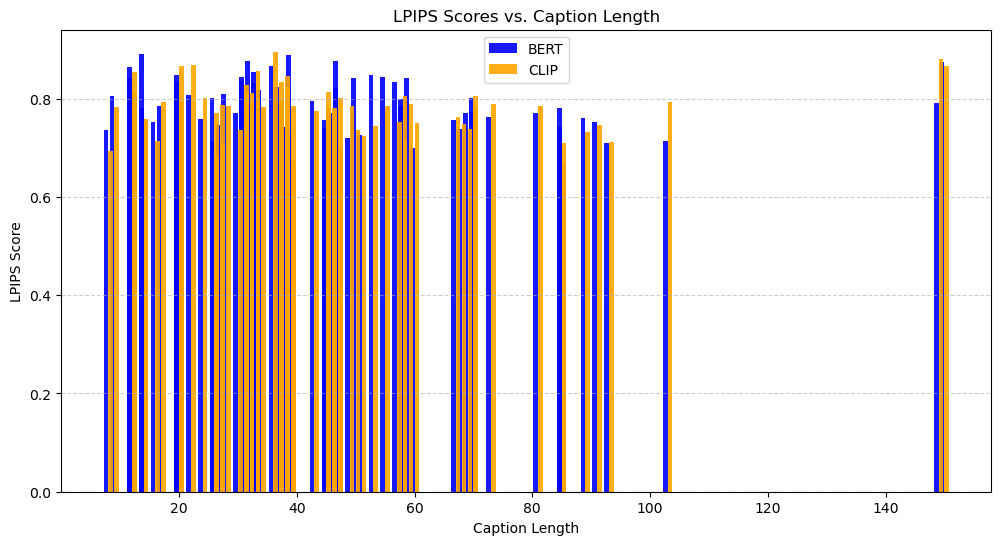

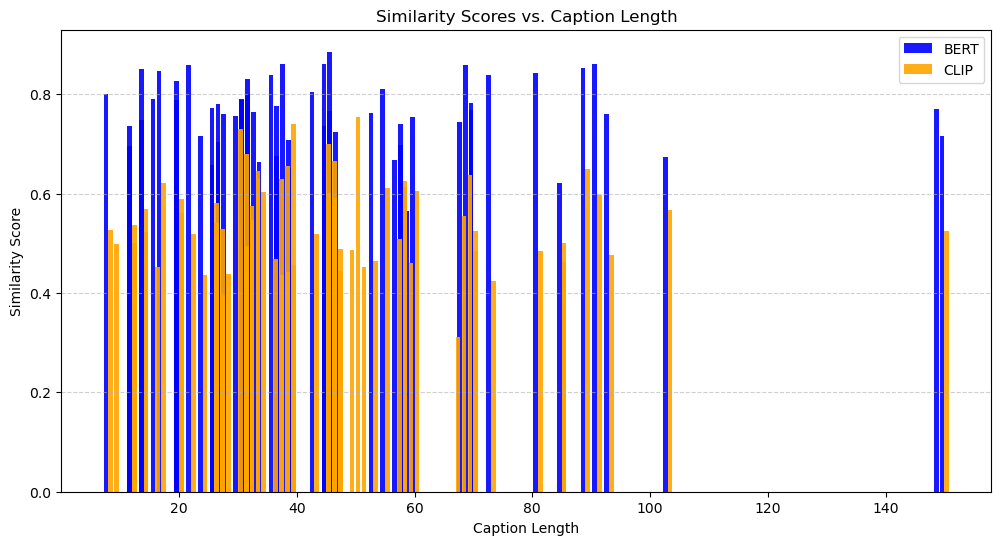

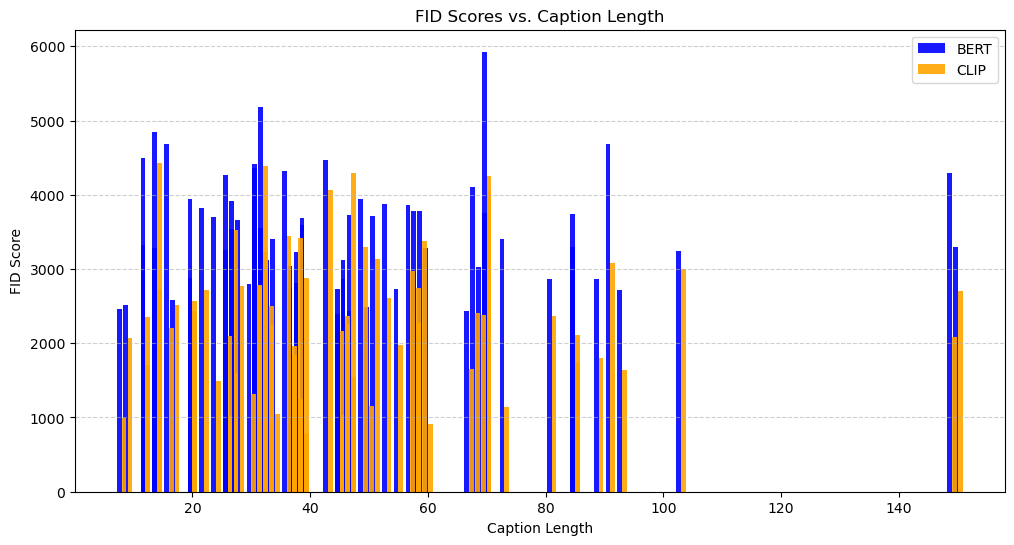

In [53]:
import matplotlib.pyplot as plt

def plot_scores_vs_caption_length(bert_scores, clip_scores, score_type):
    bert_lengths = list(bert_scores.values())
    bert_scores_values = list(bert_scores.keys())
    
    clip_lengths = list(clip_scores.values())
    clip_scores_values = list(clip_scores.keys())

    bar_width = 0.8  # Keep the bars wide

    plt.figure(figsize=(12, 6))
    
    # Plot BERT scores as bars, shift slightly left
    plt.bar([x - bar_width / 2 for x in bert_lengths], bert_scores_values, width=bar_width, label='BERT', color='blue', alpha=0.9)
    
    # Plot CLIP scores as bars, shift slightly right
    plt.bar([x + bar_width / 2 for x in clip_lengths], clip_scores_values, width=bar_width, label='CLIP', color='orange', alpha=0.9)

    # Adding titles and labels
    plt.title(f'{score_type} Scores vs. Caption Length')
    plt.xlabel('Caption Length')
    plt.ylabel(f'{score_type} Score')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)  # Grid only for y-axis to match bar plots
    plt.show()

# Example usage with your scores
# Generate LPIPS scores vs caption length
plot_scores_vs_caption_length(lpips_scores_bert, lpips_scores_clip, 'LPIPS')

# Generate Similarity scores vs caption length
plot_scores_vs_caption_length(similarity_scores_bert, similarity_scores_clip, 'Similarity')

# Generate FID scores vs caption length
plot_scores_vs_caption_length(fid_scores_bert, fid_scores_clip, 'FID')

